Tugas AVD

Nama: Yeheskiel Darmawan

Nim: 2509116027

# **Analisis Faktor yang Mempengaruhi Kinerja dan Retensi Karyawan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file = "/content/drive/MyDrive/Messy_Employee_dataset.csv"
df = pd.read_csv(file)

df

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1015,EMP2015,David,Miller,30.0,HR-California,Active,8/19/2023,NaN,david.miller@example.com,-3546212759,Good,True
1016,EMP2016,David,Johnson,30.0,Cloud Tech-Texas,Inactive,11/7/2021,100215.06,david.johnson@example.com,-2508261122,Good,True
1017,EMP2017,Charlie,Williams,40.0,Finance-New York,Active,10/4/2023,114587.11,charlie.williams@example.com,-1261632487,Average,False
1018,EMP2018,Alice,Garcia,30.0,HR-Florida,Inactive,12/16/2024,71318.79,alice.garcia@example.com,-8995729892,Good,True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Business Understanding**

Analisis ini dilakukan untuk memahami kondisi karyawan di perusahaan berdasarkan data yang tersedia. Dari dataset tersebut, terlihat bahwa terdapat informasi seperti usia, salary, pengalaman kerja, departemen, dan performance rating yang dapat digunakan untuk melihat pola tertentu. Selain itu, terdapat beberapa data yang masih kosong sehingga perlu diperhatikan sebelum analisis lebih lanjut dilakukan. Melalui analisis ini, diharapkan perusahaan bisa mendapatkan gambaran yang lebih jelas mengenai faktor yang mempengaruhi performa dan keberlangsungan kerja karyawan

## **Business Objective**

Mengetahui faktor yang paling berpengaruh terhadap kinerja dan keputusan karyawan untuk tetap bekerja atau resign, sehingga perusahaan dapat mengambil keputusan yang lebih tepat dalam mengelola SDM

## **Assess Situation**

*   **Ketersediaan Data**
Dataset sudah tersedia dan berisi informasi mengenai usia, salary, pengalaman kerja, departemen, performance rating, dan status kerja karyawan

*   **Kondisi Data**
Dari pengecekan awal, ditemukan beberapa nilai yang kosong pada kolom tertentu seperti Age dan Salary, sehingga perlu dilakukan pembersihan data sebelum analisis lebih lanjut

*   **Kesiapan Analisis**
Secara umum data sudah cukup untuk dilakukan eksplorasi, namun tetap diperlukan tahap persiapan agar hasil analisis lebih akurat dan tidak bias





## **Analytic Goals**



**Tujuan analisis dalam proyek ini adalah:**

* **Mengidentifikasi faktor yang mempengaruhi performance karyawan**
Melihat apakah variabel seperti salary, usia, dan pengalaman kerja memiliki hubungan dengan performance rating

* **Menganalisis pola karyawan yang resign**
Mengamati apakah terdapat karakteristik tertentu pada karyawan yang keluar dibandingkan dengan yang masih aktif

* **Mengevaluasi kesesuaian antara salary dan pengalaman kerja**
Menilai apakah terdapat pola yang menunjukkan hubungan yang wajar antara pengalaman kerja dan tingkat gaji

* **Memberikan gambaran awal berbasis data**
Menyusun hasil analisis sebagai dasar untuk pemahaman kondisi karyawan secara keseluruhan

## **Project Plan**

**Tahapan yang akan dilakukan dalam proyek ini meliputi:**

1.   **Business Understanding**
Memahami latar belakang permasalahan serta tujuan analisis yang ingin dicapai
2.   **Data Understanding**
Melakukan pengecekan awal terhadap struktur dataset, tipe variabel, serta keberadaan nilai yang kosong
1.   **Data Preparation**
Membersihkan dan menyiapkan data agar siap untuk proses analisis selanjutnya
2.   **Exploratory Data Analysis (EDA)**
Melakukan analisis awal untuk melihat pola atau hubungan antar variabel yang berpotensi berpengaruh terhadap kinerja dan status kerja karyawan

# **Checkpoint 2**

# **Data Understanding & Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Memuat Dataset**

In [ ]:
file = '/content/drive/MyDrive/tugas AVD/Messy_Employee_dataset.csv'

df = pd.read_csv(file)
df

,Employee_ID,First_Name,Last_Name,Age,Status,Join_Date,Salary,Performance_Score,Remote_Work,Salary_num,Years_Working,Performance_Num
0,emp1000,bob,davis,25.0,active,2021-04-02,59767.65,average,True,59767.65,4.934247,2
1,emp1001,bob,brown,30.0,active,2020-07-10,65304.66,excellent,True,65304.66,5.663014,4
2,emp1002,alice,jones,30.0,pending,2023-12-07,88145.90,good,True,88145.90,2.252055,3
3,emp1003,eva,davis,25.0,inactive,2021-11-27,69450.99,good,True,69450.99,4.279452,3
4,emp1004,frank,williams,25.0,active,2022-01-05,109324.61,poor,False,109324.61,4.172603,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1015,emp2015,david,miller,30.0,active,2023-08-19,85547.87,good,True,85547.87,2.553425,3
1016,emp2016,david,johnson,30.0,inactive,2021-11-07,100215.06,good,True,100215.06,4.334247,3
1017,emp2017,charlie,williams,40.0,active,2023-10-04,114587.11,average,False,114587.11,2.427397,2
1018,emp2018,alice,garcia,30.0,inactive,2024-12-16,71318.79,good,True,71318.79,1.224658,3


## **Data Understanding**

## Struktur Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                1020 non-null   float64
 4   Status             1020 non-null   object 
 5   Join_Date          1020 non-null   object 
 6   Salary             1020 non-null   float64
 7   Performance_Score  1020 non-null   object 
 8   Remote_Work        1020 non-null   bool   
 9   Salary_num         1020 non-null   float64
 10  Years_Working      1020 non-null   float64
 11  Performance_Num    1020 non-null   int64  
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 88.8+ KB


In [ ]:
print(df.columns)

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Status', 'Join_Date',
       'Salary', 'Performance_Score', 'Remote_Work', 'Salary_num',
       'Years_Working', 'Performance_Num'],
      dtype='object')


**Insight**:
- Dataset memiliki sejumlah baris dan kolom
- Beberapa kolom seperti Salary dan Join_Date masih bertipe object
- Perlu penyesuaian tipe data sebelum analisis lebih lanjut

## **Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Employee_ID,First_Name,Last_Name,Age,Status,Join_Date,Salary,Performance_Score,Remote_Work,Salary_num,Years_Working,Performance_Num
count,1020,1020,1020,1020.000000,1020,1020,1020.000000,1020,1020,1020.000000,1020.000000,1020.000000
unique,1020,8,8,NaN,3,760,NaN,4,2,NaN,NaN,NaN
top,emp2019,frank,brown,NaN,pending,2024-06-10,NaN,good,True,NaN,NaN,NaN
freq,1,142,148,NaN,356,5,NaN,270,513,NaN,NaN,NaN
mean,NaN,NaN,NaN,31.970588,NaN,NaN,85164.299069,NaN,NaN,85164.299069,3.617706,2.576471
std,NaN,NaN,NaN,5.136901,NaN,NaN,19638.385740,NaN,NaN,19638.385740,1.479472,1.091962
min,NaN,NaN,NaN,25.000000,NaN,NaN,50047.320000,NaN,NaN,50047.320000,1.189041,1.000000
25%,NaN,NaN,NaN,30.000000,NaN,NaN,68811.232500,NaN,NaN,68811.232500,2.352055,2.000000
50%,NaN,NaN,NaN,30.000000,NaN,NaN,85547.870000,NaN,NaN,85547.870000,3.579452,3.000000
75%,NaN,NaN,NaN,35.000000,NaN,NaN,100372.662500,NaN,NaN,100372.662500,4.906164,4.000000


**Insight:**
- Terdapat variasi nilai pada kolom numerik
- Kategori pada kolom teks menunjukkan kemungkinan inkonsistensi

## **Cek Tipe Data**

In [ ]:
df.dtypes

,0
Employee_ID,object
First_Name,object
Last_Name,object
Age,float64
Status,object
Join_Date,object
Salary,float64
Performance_Score,object
Remote_Work,bool
Salary_num,float64


**Insight:**
- Berdasarkan hasil pengecekan tipe data, kolom numerik seperti Age, Work_Experience, dan Salary_num sudah bertipe int/float sehingga siap digunakan untuk analisis statistik.
Kolom Employee_ID, Dept, dan Status bertipe object karena merupakan data kategorikal.
Secara umum, tipe data sudah sesuai dan tidak memerlukan perubahan lebih lanjut.

## **Cek Inconsistent Values**

## **Cek Seluruh Kolom Category**

In [ ]:
cols = df.select_dtypes(include='object')

for col in cols:
    print("Kolom :", col)
    print(df[col].unique())

Kolom : Employee_ID
['emp1000' 'emp1001' 'emp1002' ... 'emp2017' 'emp2018' 'emp2019']
Kolom : First_Name
['bob' 'alice' 'eva' 'frank' 'charlie' 'david' 'heidi' 'grace']
Kolom : Last_Name
['davis' 'brown' 'jones' 'williams' 'garcia' 'johnson' 'miller' 'smith']
Kolom : Status
['active' 'pending' 'inactive']
Kolom : Join_Date
['2021-04-02' '2020-07-10' '2023-12-07' '2021-11-27' '2022-01-05'
 '2020-06-10' '2020-04-03' '2022-07-17' '2023-12-08' '2022-08-04'
 '2024-07-06' '2023-09-04' '2024-03-05' '2020-10-10' '2024-06-10'
 '2021-05-29' '2024-04-23' '2024-11-28' '2024-09-19' '2020-01-02'
 '2021-05-08' '2020-09-19' '2021-03-09' '2022-02-03' '2020-02-13'
 '2020-04-30' '2023-10-02' '2020-07-12' '2023-10-11' '2021-05-24'
 '2021-05-26' '2024-11-05' '2021-08-07' '2020-04-29' '2022-10-26'
 '2023-05-03' '2023-05-02' '2021-10-05' '2022-07-27' '2021-06-27'
 '2022-06-16' '2024-12-03' '2023-05-23' '2020-07-08' '2021-06-20'
 '2024-12-13' '2022-05-30' '2023-09-27' '2021-11-11' '2022-02-22'
 '2024-08-07' '

**Insight:**

- Technology
- technology
- TECHNOLOGY

## **Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Employee_ID,0.0
First_Name,0.0
Last_Name,0.0
Age,0.0
Status,0.0
Join_Date,0.0
Salary,0.0
Performance_Score,0.0
Remote_Work,0.0
Salary_num,0.0


**Insight:**
- Beberapa kolom memiliki missing values yang signifikan.
- Perlu dilakukan imputasi atau pembersihan.

## **Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight:**
- Data duplikat dapat mempengaruhi hasil agregasi dan analisis

## **Outliers (Salary)**

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_382/2161983471.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Salary_num'] = pd.to_numeric(df['Salary'].replace('[\$,]', '', regex=True), errors='coerce')


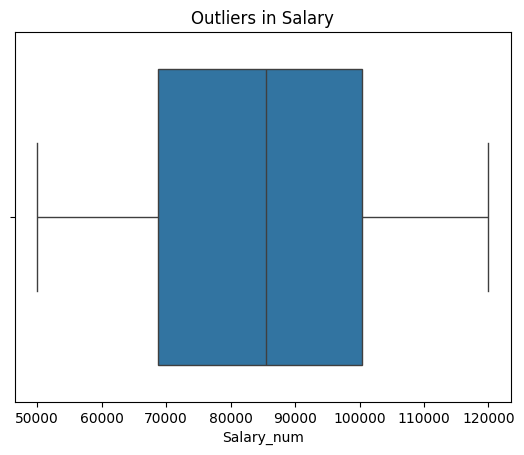

In [ ]:
df['Salary_num'] = pd.to_numeric(df['Salary'].replace('[\$,]', '', regex=True), errors='coerce')
sns.boxplot(x=df['Salary_num'])
plt.title('Outliers in Salary')
plt.show()

**Insight:**
- Terdapat nilai salary ekstrem yang perlu dianalisis lebih lanjut

# **Exploratory Data Analysis (EDA)**

## **Comparison – Average Salary per Department**

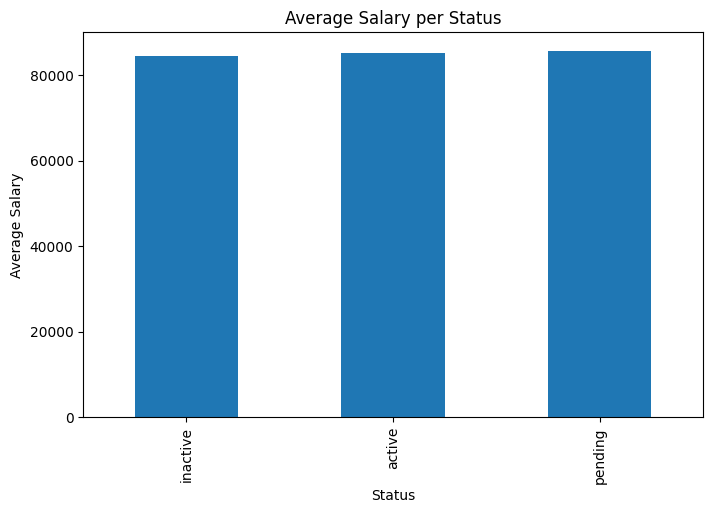

In [ ]:
plt.figure(figsize=(8,5))

df.groupby('Status')['Salary_num'].mean().sort_values().plot(kind='bar')

plt.title('Average Salary per Status')
plt.xlabel('Status')
plt.ylabel('Average Salary')

plt.show()

**Insight:**
- Grafik menunjukkan rata-rata salary berdasarkan status karyawan. Perbedaan rata-rata gaji antar status dapat memberikan gambaran mengenai struktur kompensasi di perusahaan

## **Composition – Employee Status**

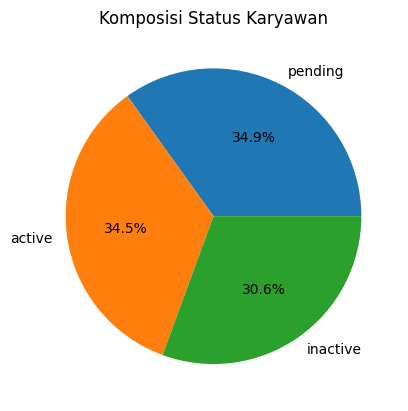

In [ ]:
df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Komposisi Status Karyawan')
plt.ylabel('')
plt.show()

**Insight:**
- Mayoritas karyawan berada pada satu kategori status tertentu

## **Distribution – Age**

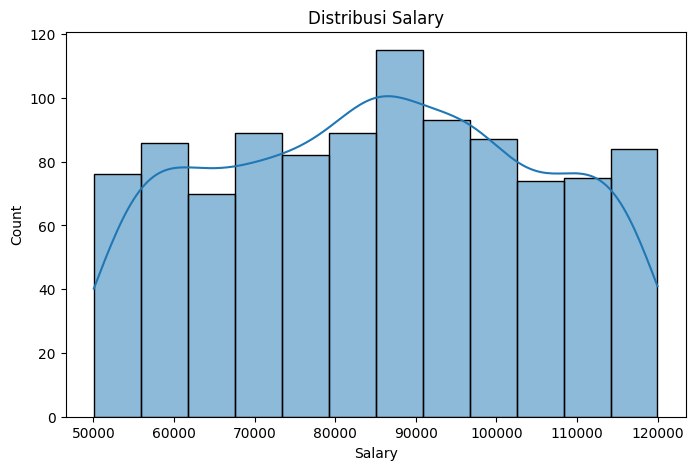

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], kde=True)
plt.title('Distribusi Salary')
plt.xlabel('Salary')
plt.show()

**Insight:**
- Distribusi usia menunjukkan pola tertentu dalam populasi karyawan

## **Relationship – Salary vs Performance Score**

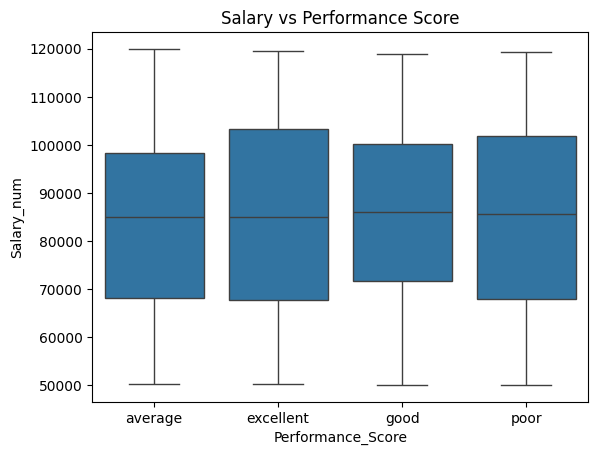

In [ ]:
sns.boxplot(x='Performance_Score', y='Salary_num', data=df)
plt.title('Salary vs Performance Score')
plt.show()

**Insight:**
- Karyawan dengan performa lebih tinggi cenderung memiliki salary lebih tinggi

# **Checkpoint 3**

In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                1020 non-null   float64
 4   Status             1020 non-null   object 
 5   Join_Date          1020 non-null   object 
 6   Salary             1020 non-null   float64
 7   Performance_Score  1020 non-null   object 
 8   Remote_Work        1020 non-null   bool   
 9   Salary_num         1020 non-null   float64
 10  Years_Working      1020 non-null   float64
 11  Performance_Num    1020 non-null   int64  
dtypes: bool(1), float64(4), int64(1), object(6)
memory usage: 88.8+ KB


,Employee_ID,First_Name,Last_Name,Age,Status,Join_Date,Salary,Performance_Score,Remote_Work,Salary_num,Years_Working,Performance_Num
count,1020,1020,1020,1020.000000,1020,1020,1020.000000,1020,1020,1020.000000,1020.000000,1020.000000
unique,1020,8,8,NaN,3,760,NaN,4,2,NaN,NaN,NaN
top,emp2019,frank,brown,NaN,pending,2024-06-10,NaN,good,True,NaN,NaN,NaN
freq,1,142,148,NaN,356,5,NaN,270,513,NaN,NaN,NaN
mean,NaN,NaN,NaN,31.970588,NaN,NaN,85164.299069,NaN,NaN,85164.299069,3.617706,2.576471
std,NaN,NaN,NaN,5.136901,NaN,NaN,19638.385740,NaN,NaN,19638.385740,1.479472,1.091962
min,NaN,NaN,NaN,25.000000,NaN,NaN,50047.320000,NaN,NaN,50047.320000,1.189041,1.000000
25%,NaN,NaN,NaN,30.000000,NaN,NaN,68811.232500,NaN,NaN,68811.232500,2.352055,2.000000
50%,NaN,NaN,NaN,30.000000,NaN,NaN,85547.870000,NaN,NaN,85547.870000,3.579452,3.000000
75%,NaN,NaN,NaN,35.000000,NaN,NaN,100372.662500,NaN,NaN,100372.662500,4.906164,4.000000


## **Tipe Data**
Kolom tanggal diubah menjadi datetime agar dapat digunakan untuk analisis berbasis waktu.

In [ ]:
if 'Join_Date' in df.columns:
    df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_ID        1020 non-null   object        
 1   First_Name         1020 non-null   object        
 2   Last_Name          1020 non-null   object        
 3   Age                1020 non-null   float64       
 4   Status             1020 non-null   object        
 5   Join_Date          1020 non-null   datetime64[ns]
 6   Salary             1020 non-null   float64       
 7   Performance_Score  1020 non-null   object        
 8   Remote_Work        1020 non-null   bool          
 9   Salary_num         1020 non-null   float64       
 10  Years_Working      1020 non-null   float64       
 11  Performance_Num    1020 non-null   int64         
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 88.8+ KB


## **Missing Value**
Missing value numerik diisi menggunakan median karena lebih tahan terhadap outlier.

In [ ]:
print('Missing Value Sebelum:')
display(df.isnull().sum())

Missing Value Sebelum:


,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Status,0
Join_Date,0
Salary,0
Performance_Score,0
Remote_Work,0
Salary_num,0


In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    median_value = df[col].median()
    print(f'Mengisi {col} dengan median =', median_value)
    df[col] = df[col].fillna(median_value)

Mengisi Age dengan median = 30.0
Mengisi Salary dengan median = 85547.87
Mengisi Salary_num dengan median = 85547.87
Mengisi Years_Working dengan median = 3.5794520547945208
Mengisi Performance_Num dengan median = 3.0


Kolom kategorikal diisi menggunakan modus untuk mempertahankan kategori dominan.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print('Missing Value Sesudah:')
display(df.isnull().sum())

Missing Value Sesudah:


,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Status,0
Join_Date,0
Salary,0
Performance_Score,0
Remote_Work,0
Salary_num,0


## **Inconsistent Values**
Standardisasi teks dilakukan agar tidak terjadi perbedaan kategori akibat kapitalisasi atau spasi.

In [ ]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

## Duplicate Handling
Data duplikat dihapus untuk menghindari bias analisis.

In [ ]:
print('Duplicate sebelum:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicate sesudah:', df.duplicated().sum())

Duplicate sebelum: 0
Duplicate sesudah: 0


## **Outlier**
Metode IQR digunakan untuk mendeteksi nilai ekstrem tanpa asumsi distribusi normal.

In [ ]:
outlier_cols = ['Salary','Age']

for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]

print('Jumlah data setelah outlier:', df.shape)

Jumlah data setelah outlier: (1020, 12)


## **Construct Data**
Fitur Years_Working dibuat untuk mengetahui lama bekerja karyawan.

In [ ]:
if 'Join_Date' in df.columns:
    today = pd.to_datetime('today')
    df['Years_Working'] = (today - df['Join_Date']).dt.days / 365

Encoding performa dilakukan agar dapat dianalisis secara numerik.

In [ ]:
performance_map = {'poor':1,'average':2,'good':3,'excellent':4}

if 'Performance_Score' in df.columns:
    df['Performance_Num'] = df['Performance_Score'].map(performance_map)

## **Data Reduction**
Kolom yang tidak relevan seperti email dan phone dihapus.

In [ ]:
drop_cols = ['Email','Phone','Department_Region']
drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(columns=drop_cols, inplace=True)

## **Save Dataset**

In [ ]:
df.to_csv('/content/drive/MyDrive/tugas AVD/Messy_Employee_dataset.csv', index=False)
print('Dataset berhasil disimpan')

Dataset berhasil disimpan



# **Checkpoint 4**

## **Load Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/tugas AVD/Messy_Employee_dataset.csv')
df.head()

,Employee_ID,First_Name,Last_Name,Age,Status,Join_Date,Salary,Performance_Score,Remote_Work,Salary_num,Years_Working,Performance_Num
0,emp1000,bob,davis,25.0,active,2021-04-02,59767.65,average,True,59767.65,4.934247,2
1,emp1001,bob,brown,30.0,active,2020-07-10,65304.66,excellent,True,65304.66,5.663014,4
2,emp1002,alice,jones,30.0,pending,2023-12-07,88145.90,good,True,88145.90,2.252055,3
3,emp1003,eva,davis,25.0,inactive,2021-11-27,69450.99,good,True,69450.99,4.279452,3
4,emp1004,frank,williams,25.0,active,2022-01-05,109324.61,poor,False,109324.61,4.172603,1


## **Bar Chart**

**Jumlah Karyawan Berdasarkan Status**

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

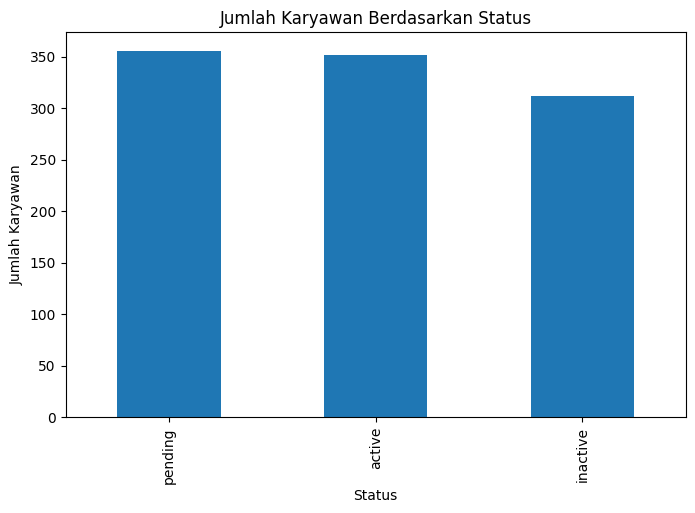

In [ ]:
plt.figure(figsize=(8,5))
df['Status'].value_counts().plot(kind='bar')

plt.title('Jumlah Karyawan Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Jumlah Karyawan')

plt.show()


**Insight:**  
Grafik bar menunjukkan distribusi jumlah karyawan berdasarkan status pekerjaan. Dari visualisasi ini dapat dilihat bahwa sebagian besar karyawan berada pada status aktif dibandingkan dengan status lainnya.

**Action:**  
Perusahaan dapat menggunakan informasi ini untuk memantau kondisi tenaga kerja serta mengevaluasi tingkat retensi karyawan dalam organisasi.

## **Pie Chart**

**Proporsi Gender**

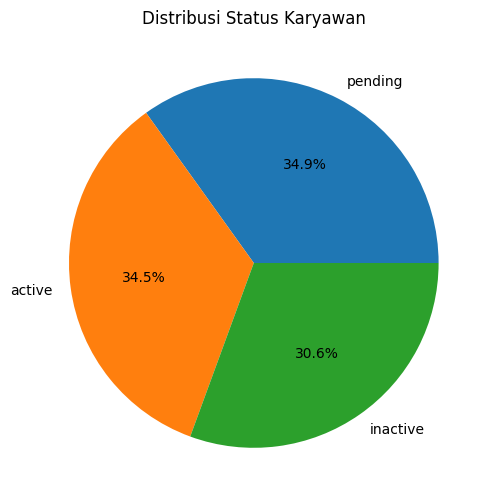

In [ ]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')

plt.title('Distribusi Status Karyawan')

plt.show()


**Insight:**  
Menunjukkan perbandingan jumlah karyawan berdasarkan gender.

**Action:**  
Perusahaan dapat mengevaluasi keberagaman tenaga kerja.


## **Line Chart**

**Salary Berdasarkan Experience**

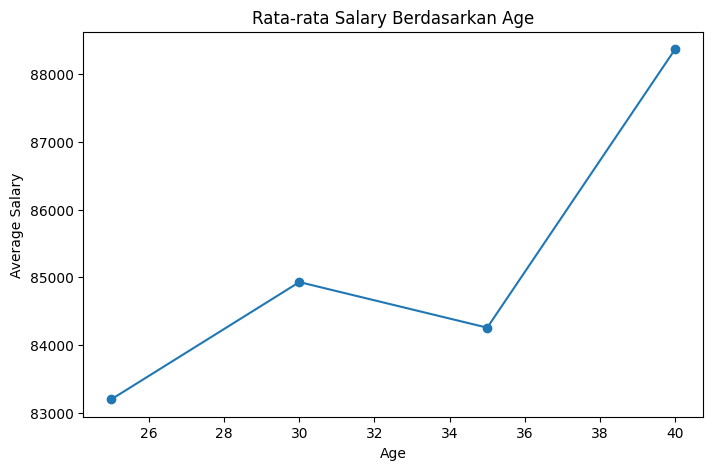

In [ ]:
salary_by_age = df.groupby('Age')['Salary'].mean()

plt.figure(figsize=(8,5))
plt.plot(salary_by_age.index, salary_by_age.values, marker='o')

plt.title('Rata-rata Salary Berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Average Salary')

plt.show()


**Insight:**  
Semakin tinggi experience, salary cenderung meningkat.

**Action:**  
Pengalaman kerja bisa menjadi pertimbangan utama dalam sistem penggajian.


## **Histogram**

**Distribusi Usia**

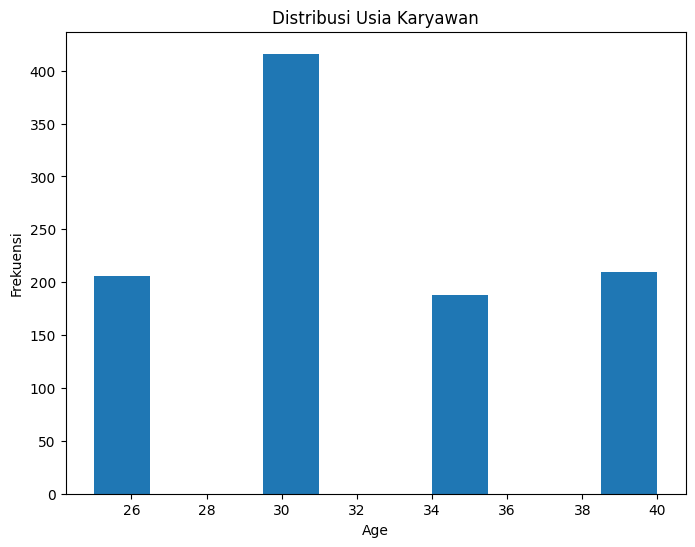

In [ ]:

plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins=10)

plt.title('Distribusi Usia Karyawan')
plt.xlabel('Age')
plt.ylabel('Frekuensi')

plt.show()



**Insight:**  
Menunjukkan sebaran usia karyawan.

**Action:**  
Berguna untuk perencanaan tenaga kerja di masa depan.


## **Box Plot**

**Salary Berdasarkan Department**

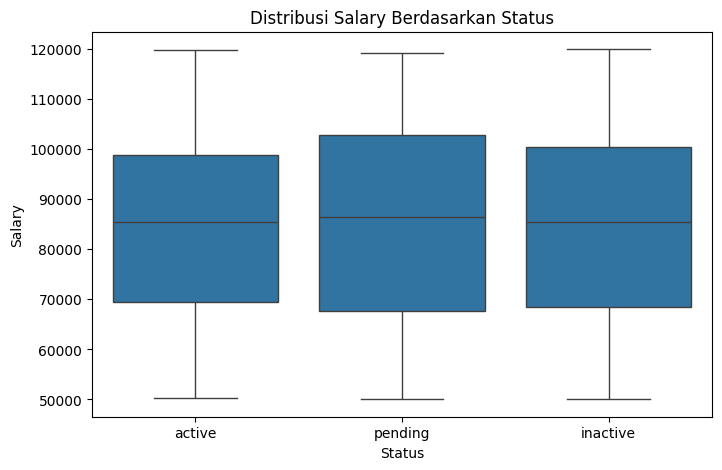

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Status', y='Salary_num', data=df)

plt.title('Distribusi Salary Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Salary')

plt.show()


**Insight:**  
Box plot menunjukkan distribusi salary pada setiap status karyawan. Dari grafik ini dapat terlihat median salary, rentang distribusi, serta kemungkinan adanya outlier pada beberapa kategori status.

**Action:**  
Perusahaan dapat mengevaluasi struktur penggajian antar status karyawan untuk memastikan sistem kompensasi yang adil dan sesuai dengan tanggung jawab pekerjaan.

## **Scatter Plot**

**Age and Salary**

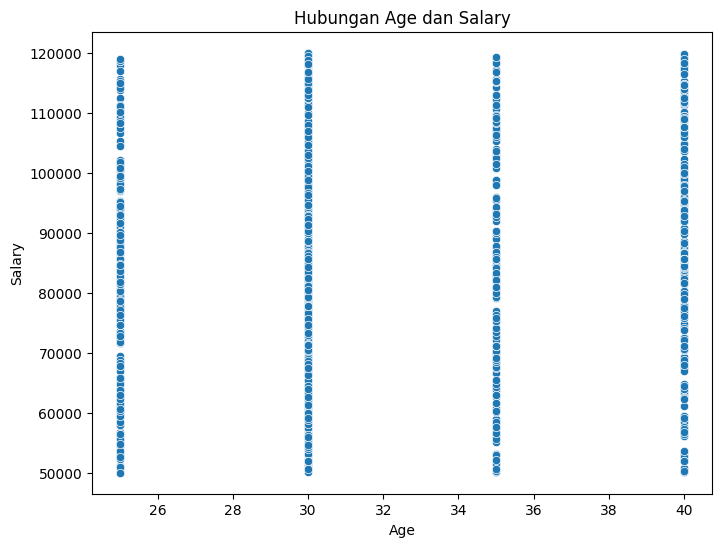

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Salary', data=df)

plt.title('Hubungan Age dan Salary')

plt.show()



**Insight:**  
Menunjukkan hubungan antara usia dan salary.

**Action:**  
Perusahaan dapat melihat faktor yang mempengaruhi salary.


## **Heatmap Korelasi**

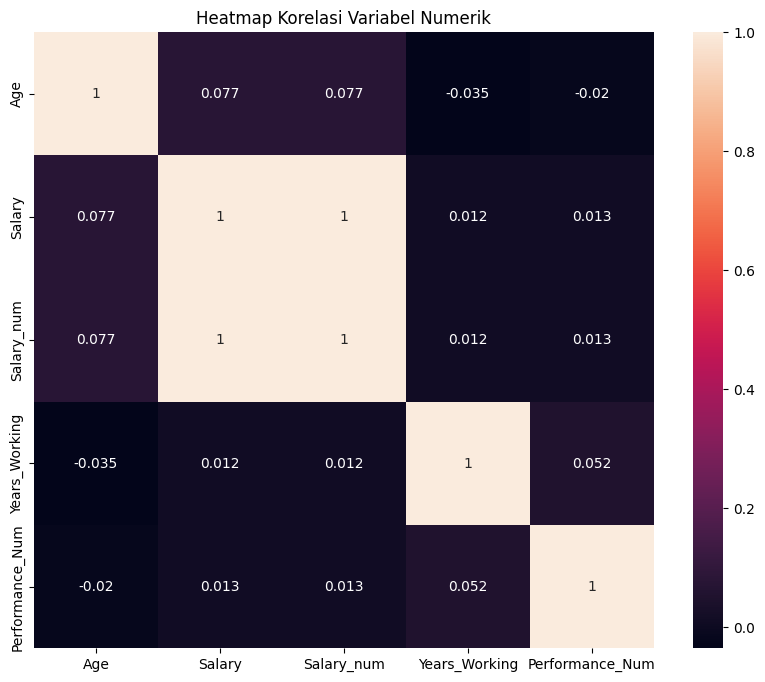

In [ ]:
plt.figure(figsize=(10,8))

numerical = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numerical.corr(), annot=True)

plt.title('Heatmap Korelasi Variabel Numerik')

plt.show()



**Insight:**  
Menunjukkan hubungan antar variabel numerik.

**Action:**  
Membantu memahami faktor yang mempengaruhi salary atau performa.
